   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

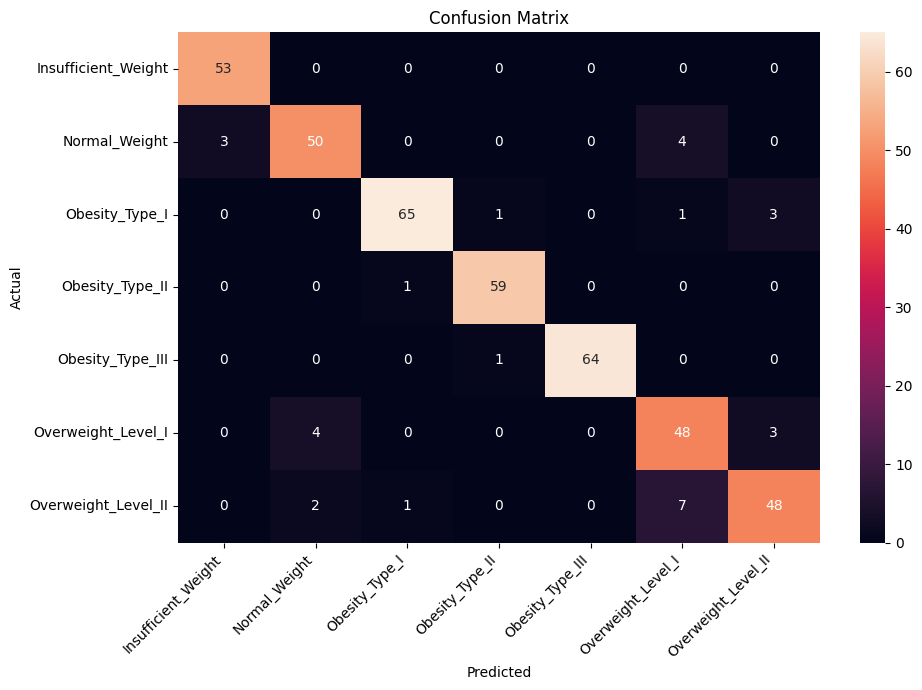


Sample predictions:
                 Actual            Predicted
0   Overweight_Level_II  Overweight_Level_II
1        Obesity_Type_I      Obesity_Type_II
2      Obesity_Type_III     Obesity_Type_III
3    Overweight_Level_I   Overweight_Level_I
4        Obesity_Type_I       Obesity_Type_I
5        Obesity_Type_I       Obesity_Type_I
6        Obesity_Type_I       Obesity_Type_I
7   Overweight_Level_II  Overweight_Level_II
8      Obesity_Type_III      Obesity_Type_II
9       Obesity_Type_II      Obesity_Type_II
10        Normal_Weight        Normal_Weight
11      Obesity_Type_II      Obesity_Type_II
12        Normal_Weight        Normal_Weight
13      Obesity_Type_II      Obesity_Type_II
14      Obesity_Type_II      Obesity_Type_II


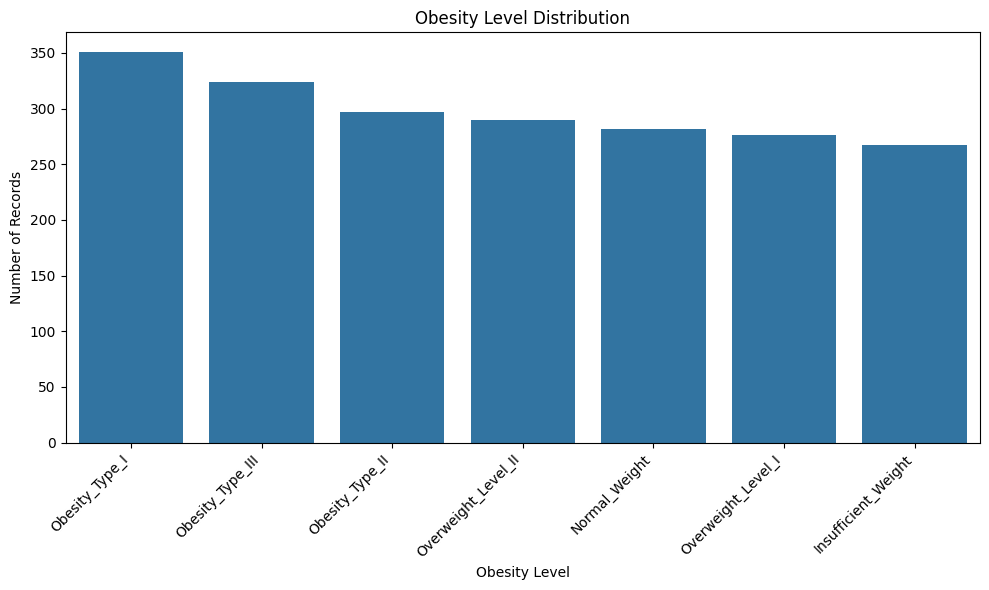


Enter details for a new person
Gender (Male/Female): Male
Age: 23
Height in meters: 1.8
Weight in kg: 62
Family history with overweight (yes/no): no
Frequently eat high caloric food (yes/no): yes
Frequency of vegetable consumption (1-3): 3
Number of main meals per day: 3
Food consumption between meals (Never/Sometimes/Frequently/Always): Sometimes
Do you smoke? (yes/no): no
Daily water consumption (1-3 liters): 2.5
Monitor calorie consumption (yes/no): no
Physical activity frequency (0-3): 1
Time using technology devices (0-2): 2
Alcohol consumption (Never/Sometimes/Frequently/Always): Never
Main transportation method: Bike

-----------------------------
Prediction
-----------------------------
Predicted Obesity Level: Normal_Weight


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Load dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

df = pd.read_csv(url)

print(df.head())
print("\nShape:", df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()


# Separate features and target
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

print("\nTarget distribution:")
print(y.value_counts())


# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include="object").columns.tolist()
numerical_columns = X.select_dtypes(exclude="object").columns.tolist()

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)


# Split the data before preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Encode categorical columns
encoder = OneHotEncoder(
    sparse_output=False,
    drop="first",
    handle_unknown="ignore"
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_columns]
)

X_test_encoded = encoder.transform(
    X_test[categorical_columns]
)

encoded_columns = encoder.get_feature_names_out(
    categorical_columns
)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)


# Combine numerical and encoded columns
X_train_processed = pd.concat(
    [X_train[numerical_columns], X_train_encoded],
    axis=1
)

X_test_processed = pd.concat(
    [X_test[numerical_columns], X_test_encoded],
    axis=1
)


# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)


# Train One-vs-One Logistic Regression
model = OneVsOneClassifier(
    LogisticRegression(max_iter=1000, random_state=42)
)

model.fit(X_train_scaled, y_train)


# Make predictions
y_pred = model.predict(X_test_scaled)


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Actual vs predicted values
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample predictions:")
print(results.head(15))


# Class distribution
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="NObeyesdad",
    order=df["NObeyesdad"].value_counts().index
)

plt.title("Obesity Level Distribution")
plt.xlabel("Obesity Level")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Predict for new data

print("\nEnter details for a new person")

gender = input("Gender (Male/Female): ")
age = float(input("Age: "))
height = float(input("Height in meters: "))
weight = float(input("Weight in kg: "))

family_history = input(
    "Family history with overweight (yes/no): "
)

favc = input(
    "Frequently eat high caloric food (yes/no): "
)

fcvc = float(input(
    "Frequency of vegetable consumption (1-3): "
))

ncp = float(input(
    "Number of main meals per day: "
))

caec = input(
    "Food consumption between meals "
    "(Never/Sometimes/Frequently/Always): "
)

smoke = input("Do you smoke? (yes/no): ")

ch2o = float(input(
    "Daily water consumption (1-3 liters): "
))

scc = input(
    "Monitor calorie consumption (yes/no): "
)

faf = float(input(
    "Physical activity frequency (0-3): "
))

tue = float(input(
    "Time using technology devices (0-2): "
))

calc = input(
    "Alcohol consumption "
    "(Never/Sometimes/Frequently/Always): "
)

mtrans = input(
    "Main transportation method: "
)


# Create a DataFrame from the user's input

new_person = pd.DataFrame({
    "Gender": [gender],
    "Age": [age],
    "Height": [height],
    "Weight": [weight],
    "family_history_with_overweight": [family_history],
    "FAVC": [favc],
    "FCVC": [fcvc],
    "NCP": [ncp],
    "CAEC": [caec],
    "SMOKE": [smoke],
    "CH2O": [ch2o],
    "SCC": [scc],
    "FAF": [faf],
    "TUE": [tue],
    "CALC": [calc],
    "MTRANS": [mtrans]
})


# Encode categorical values

new_encoded = encoder.transform(
    new_person[categorical_columns]
)

new_encoded_df = pd.DataFrame(
    new_encoded,
    columns=encoder.get_feature_names_out(categorical_columns)
)


# Combine numerical and encoded values

new_processed = pd.concat(
    [
        new_person[numerical_columns].reset_index(drop=True),
        new_encoded_df.reset_index(drop=True)
    ],
    axis=1
)


# Match the same column order used during training

new_processed = new_processed[
    X_train_processed.columns
]


# Scale the new data

new_scaled = scaler.transform(new_processed)


# Make prediction

prediction = model.predict(new_scaled)

print("\n-----------------------------")
print("Prediction")
print("-----------------------------")
print("Predicted Obesity Level:", prediction[0])

